In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Main dataset folder
data_dir = "images_original"

# Store image paths + labels
filepaths = []
labels = []

# Read all images
for genre in os.listdir(data_dir):
    genre_path = os.path.join(data_dir, genre)

    for img in os.listdir(genre_path):
        filepaths.append(os.path.join(genre_path, img))
        labels.append(genre)

# Create dataframe
df = pd.DataFrame({
    "filename": filepaths,
    "class": labels
})

# 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=42
)

# 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

# Normalize images
datagen = ImageDataGenerator(rescale=1./255)

# Train data
train_data = datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

# Validation data
val_data = datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

# Test data
test_data = datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 699 validated image filenames belonging to 10 classes.
Found 150 validated image filenames belonging to 10 classes.
Found 150 validated image filenames belonging to 10 classes.


c:\python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.1273 - loss: 2.3489 - val_accuracy: 0.1067 - val_loss: 2.2531
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.1717 - loss: 2.1998 - val_accuracy: 0.1733 - val_loss: 2.0820
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.2504 - loss: 2.0601 - val_accuracy: 0.3400 - val_loss: 1.8853
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.3233 - loss: 1.9197 - val_accuracy: 0.4067 - val_loss: 1.7671
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.3591 - loss: 1.7974 - val_accuracy: 0.4133 - val_loss: 1.6421
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.4249 - loss: 1.6168 - val_accuracy: 0.4667 - val_loss: 1.5627
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.4707 - loss: 1.5643 - val_accuracy: 0.5267 - val_loss: 1.4748
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.5093 - loss: 1.4145 - val_accuracy: 0.

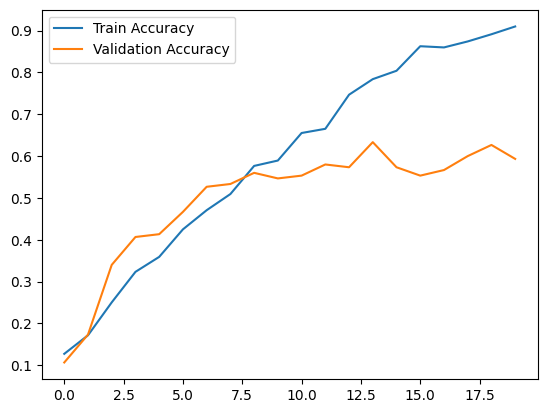

In [2]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Build CNN Model
cnn = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

# Compile Model
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# Evaluate on Test Data
test_loss, test_acc = cnn.evaluate(test_data)

print("Test Accuracy:", test_acc)

# Accuracy Graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Save Model
cnn.save("music_genre_cnn.h5")